# COPF results plotting (Base vs Base+COPF)

This notebook plots **time-series** metrics across **PRE / DEPLOY / POST** and prints a **phase summary table**.

✅ You only need to set two paths:
- `BASE_PATH`  (Base method log)
- `COPF_PATH`  (Base+COPF log)

Supported input:
- **CSV** (recommended)
- **DOCX** containing pasted CSV blocks (like the files you shared) — optional fallback

The code expects columns like:
`step, phase, ndcg@10, mrr, hits@10, deploy_hit@topk, gTE_gap, gCal_max`  
(you can plot any other columns too).


In [ ]:
# ====== 你只需要改这里 ======
# 输入既可以是：
# 1) 单个 CSV 路径：   "path/to/file.csv"
# 2) glob：           "path/to/*round*.csv"
# 3) list：           ["r1.csv", "r2.csv", "r3.csv"]
#
# NOTE: 如果你每个文件只有一个 round，那么“多文件=多 seed”，就能得到 std 阴影。

BASE_INPUT = ["/data1/shengen/fairlink/out/batch_synth_bipartite_v1_20260119_113519/base/graphmixer/seed42/opp_copf_metrics.csv", '/data1/shengen/fairlink/out/batch_synth_bipartite_v1_20260119_113519/base/graphmixer/seed43/opp_copf_metrics.csv']
COPF_INPUT = ['/data1/shengen/fairlink/out/batch_synth_bipartite_v1_20260119_113403/copf/graphmixer/seed42/opp_copf_metrics.csv', '/data1/shengen/fairlink/out/batch_synth_bipartite_v1_20260119_113403/copf/graphmixer/seed43/opp_copf_metrics.csv']

TITLE = "Dataset=Synthetic | Backbone=GraphMixer"
OUT_FIG_PDF = "copf_timeseries_mean_std.pdf"
OUT_FIG_PNG = "copf_timeseries_mean_std.png"

# 指标（按你论文表格那套）
UTILITY_METRICS  = ["ndcg@10", "mrr", "hits@10", "deploy_hit@topk"]
FAIRNESS_METRICS = ["gTE_gap", "gCal_max"]

# 平滑（1 = 不平滑；3/5 会更“论文感”一点）
SMOOTH_WINDOW = 1

# 画图风格
SHOW_STD_SHADE = True          # mean ± std 阴影
SHOW_SEED_LINES = False    


In [24]:
# ====== 你只需要改这里 ======
# 输入既可以是：
# 1) 单个 CSV 路径：   "path/to/file.csv"
# 2) glob：           "path/to/*round*.csv"
# 3) list：           ["r1.csv", "r2.csv", "r3.csv"]
#
# NOTE: 如果你每个文件只有一个 round，那么“多文件=多 seed”，就能得到 std 阴影。

BASE_INPUT = ["/data1/shengen/fairlink/out/batch_synth_bipartite_v1_20260119_113519/base/graphmixer/seed42/opp_copf_metrics.csv", '/data1/shengen/fairlink/out/batch_synth_bipartite_v1_20260119_113519/base/graphmixer/seed43/opp_copf_metrics.csv']
COPF_INPUT = ['/data1/shengen/fairlink/out/batch_synth_bipartite_v1_20260119_113403/copf/graphmixer/seed42/opp_copf_metrics.csv', '/data1/shengen/fairlink/out/batch_synth_bipartite_v1_20260119_113403/copf/graphmixer/seed43/opp_copf_metrics.csv']

TITLE = "Dataset=??? | Backbone=???"
OUT_FIG_PDF = "copf_timeseries_mean_std.pdf"
OUT_FIG_PNG = "copf_timeseries_mean_std.png"

# 指标（按你论文表格那套）
UTILITY_METRICS  = ["ndcg@10", "mrr", "hits@10", "deploy_hit@topk"]
FAIRNESS_METRICS = ["gTE_gap", "gCal_max"]

# 统一成小写（因为 notebook 会把 CSV 列名全部 lower-case）
UTILITY_METRICS  = [m.strip().lower() for m in UTILITY_METRICS]
FAIRNESS_METRICS = [m.strip().lower() for m in FAIRNESS_METRICS]

# 平滑（1 = 不平滑；3/5 会更“论文感”一点）
SMOOTH_WINDOW = 1

# 画图风格
SHOW_STD_SHADE = True          # mean ± std 阴影
SHOW_SEED_LINES = False        # 你说现在不要单 seed 细线 -> 默认 False


In [25]:
import os, re, glob
from io import StringIO
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Optional: docx parsing fallback (如果你以后还是想直接读 docx)
try:
    from docx import Document
    DOCX_OK = True
except Exception:
    DOCX_OK = False

# -----------------------
# Plot aesthetics (paper-ish)
# -----------------------
PALETTE = {
    "base":  "#4965b0",
    "copf":  "#a30543",
    "pre":   "#e9f4a3",
    "deploy":"#fbda83",
    "post":  "#80cba4",
    # extra colors (备用)
    "c2": "#f36f43",
    "c3": "#fbda83",
    "c4": "#e9f4a3",
    "c5": "#80cba4",
    "c6": "#4965b0",
}

plt.rcParams.update({
    "figure.dpi": 160,
    "savefig.dpi": 320,
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 13,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "axes.facecolor": "#fcfbfa",   # very light background
})

# -----------------------
# Utilities: loading & cleaning
# -----------------------
SEED_COL_CANDIDATES = ["seed", "round", "run", "trial"]

def _normalize_cols(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = [c.strip().lower() for c in df.columns]
    # unify common variants
    df = df.rename(columns={
        "time_step": "step",
        "t": "step",
        "phase_name": "phase",
        "deployhit@topk": "deploy_hit@topk",
        "deploy_hit@topk ": "deploy_hit@topk",
    })
    return df

def _infer_seed_col(df: pd.DataFrame, candidates=SEED_COL_CANDIDATES) -> str:
    cols = set(df.columns)
    for c in candidates:
        if c in cols:
            return c
    return ""

def _ensure_seed_col(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    seed_col = _infer_seed_col(df)
    if not seed_col:
        df["seed"] = 0
    elif seed_col != "seed":
        df = df.rename(columns={seed_col: "seed"})
    df["seed"] = pd.to_numeric(df["seed"], errors="coerce").fillna(0).astype(int)
    return df

def _infer_seed_from_path(path: str, fallback: int) -> int:
    # try common patterns: round1 / seed2 / r3 / run4
    base = os.path.basename(path).lower()
    m = re.search(r"(round|seed|run|trial|r)(\d+)", base)
    if m:
        return int(m.group(2))
    m = re.search(r"(\d+)", base)
    if m:
        return int(m.group(1))
    return int(fallback)

def load_csv(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    df = _normalize_cols(df)
    if "step" not in df.columns or "phase" not in df.columns:
        raise ValueError(f"[{path}] 必须至少包含列: step, phase")
    df["phase"] = df["phase"].astype(str).str.lower()
    df["step"] = pd.to_numeric(df["step"], errors="coerce")
    df = df.dropna(subset=["step"]).copy()
    df["step"] = df["step"].astype(int)
    df = _ensure_seed_col(df)
    return df

def load_docx_as_df(path: str) -> pd.DataFrame:
    '''Parse docx that contains one or more CSV chunks beginning with "step,phase," lines.'''
    if not DOCX_OK:
        raise RuntimeError("python-docx is not installed, cannot load .docx")
    doc = Document(path)
    text = "\n".join(p.text for p in doc.paragraphs)
    lines = [ln.strip() for ln in text.splitlines()]

    chunks = []
    i = 0
    while i < len(lines):
        ln = lines[i]
        if ln.lower().startswith("step,phase,"):
            header = ln
            data = [header]
            i += 1
            while i < len(lines) and re.match(r"^\d+", lines[i] or ""):
                data.append(lines[i])
                i += 1
            chunks.append("\n".join(data))
        else:
            i += 1

    if not chunks:
        raise ValueError(f"[{path}] 没有找到以 'step,phase,' 开头的 CSV chunk；建议先导出为 .csv 再画图。")

    dfs = []
    for idx, chunk in enumerate(chunks):
        dfi = pd.read_csv(StringIO(chunk))
        dfi = _normalize_cols(dfi)
        dfi = _ensure_seed_col(dfi)
        # docx 往往一段就是一个 round -> 用 idx 当 seed
        if dfi["seed"].nunique() == 1:
            dfi["seed"] = idx
        dfs.append(dfi)

    df = pd.concat(dfs, ignore_index=True)
    return df

def load_any(path: str) -> pd.DataFrame:
    ext = os.path.splitext(path)[1].lower()
    if ext == ".csv":
        return load_csv(path)
    if ext == ".docx":
        return load_docx_as_df(path)
    raise ValueError(f"不支持的文件类型: {ext}")

def expand_inputs(inp):
    '''Return a list of file paths from str/list.'''
    if isinstance(inp, (list, tuple)):
        files = list(inp)
    elif isinstance(inp, str):
        # glob pattern or single path
        if any(ch in inp for ch in ["*", "?", "["]):
            files = sorted(glob.glob(inp))
        else:
            files = [inp]
    else:
        raise TypeError("输入必须是 str 或 list")
    files = [f for f in files if f and os.path.exists(f)]
    if not files:
        raise FileNotFoundError("没有找到任何输入文件，请检查路径或 glob pattern")
    return files

def load_logs(inp, label: str) -> pd.DataFrame:
    files = expand_inputs(inp)
    dfs = []
    for idx, path in enumerate(files):
        df = load_any(path)
        df = _normalize_cols(df)
        df = _ensure_seed_col(df)
        # If this file does not contain multiple seeds, assign one seed id per file
        if df["seed"].nunique() == 1:
            df["seed"] = _infer_seed_from_path(path, fallback=idx)
        df["source_file"] = os.path.basename(path)
        df["label"] = label
        dfs.append(df)
    out = pd.concat(dfs, ignore_index=True)
    # keep only main phases (pre/deploy/post)
    out["phase"] = out["phase"].astype(str).str.lower()
    out = out[out["phase"].isin(["pre", "deploy", "post"])].copy()
    return out

# -----------------------
# Aggregation helpers
# -----------------------
def smooth_series(y: pd.Series, window: int) -> np.ndarray:
    y = pd.to_numeric(y, errors="coerce").astype(float)
    if window is None or window <= 1:
        return y.to_numpy()
    return y.rolling(window=window, min_periods=1, center=True).mean().to_numpy()

def aggregate_steps(df: pd.DataFrame, metric: str) -> pd.DataFrame:
    '''Aggregate metric over seeds per step: columns [step, mean, std, n_seed].'''
    d = df.copy()
    if metric not in d.columns:
        return pd.DataFrame({"step": sorted(d["step"].unique()), "mean": np.nan, "std": np.nan, "n_seed": 0})
    d[metric] = pd.to_numeric(d[metric], errors="coerce")
    d = d.dropna(subset=[metric, "step", "seed"])
    # If duplicates exist for (seed, step), average them first.
    d = d.groupby(["seed", "step"], as_index=False)[metric].mean()
    agg = d.groupby("step")[metric].agg(["mean", "std", "count"]).reset_index()
    agg = agg.rename(columns={"count": "n_seed"})
    # if only one seed contributes -> std might be NaN, set 0
    agg["std"] = agg["std"].fillna(0.0)
    return agg

def get_phase_spans(df: pd.DataFrame):
    '''Return ordered spans [(phase, start, end)] from df with columns step, phase.'''
    spans = []
    for ph in ["pre", "deploy", "post"]:
        dph = df[df["phase"] == ph]
        if len(dph) == 0:
            continue
        spans.append((ph, int(dph["step"].min()), int(dph["step"].max())))
    spans = sorted(spans, key=lambda x: x[1])
    return spans

# Pretty labels for plots
METRIC_LABEL = {
    "ndcg@10": "NDCG@10",
    "mrr": "MRR",
    "hits@10": "Hits@10",
    "deploy_hit@topk": "DeployHit@TopK",
    "gTE_gap": r"$g\mathrm{TE}_{\mathrm{gap}}$",
    "gCal_max": r"$g\mathrm{Cal}_{\max}$",
    "gte_gap": r"$g\mathrm{TE}_{\mathrm{gap}}$",
    "gcal_max": r"$g\mathrm{Cal}_{\max}$",
}
def _label(metric: str) -> str:
    return METRIC_LABEL.get(metric, metric)

# -----------------------
# Phase summary table (mean±std over seeds; worst-case in phase)
# -----------------------
def phase_summary_table(df: pd.DataFrame, metrics, higher_is_better: dict):
    '''mean±std over seeds; worst-case in phase in parentheses.'''
    d = df.copy()
    d = _ensure_seed_col(d)
    d = d.dropna(subset=["step"])
    d["phase"] = d["phase"].astype(str).str.lower()

    for m in metrics:
        if m in d.columns:
            d[m] = pd.to_numeric(d[m], errors="coerce")

    per_seed = d.groupby(["seed","phase"], as_index=False)[metrics].mean()

    rows = []
    for phase in ["pre","deploy","post"]:
        ps = per_seed[per_seed["phase"] == phase]
        if ps.empty:
            continue

        raw_phase = d[d["phase"] == phase]

        row = {"phase": phase}
        for m in metrics:
            mu = ps[m].mean()
            sd = ps[m].std(ddof=1) if ps[m].nunique() > 1 else 0.0

            if higher_is_better.get(m, True):
                worst = raw_phase[m].min()
            else:
                worst = raw_phase[m].max()

            row[m] = f"{mu:.4f}±{sd:.4f} ({worst:.4f})"
        rows.append(row)

    return pd.DataFrame(rows)

# -----------------------
# Main plot: stacked metrics, mean±std, phase background
# -----------------------
def plot_timeseries(base_df: pd.DataFrame, copf_df: pd.DataFrame,
                    utility_metrics, fairness_metrics,
                    title="", smooth_window=1,
                    show_seed_lines=False, show_std_shade=True,
                    out_pdf=None, out_png=None):

    metrics = list(utility_metrics) + list(fairness_metrics)
    n = len(metrics)

    fig, axes = plt.subplots(
        n, 1,
        figsize=(9.6, 1.85*n),
        sharex=True,
        constrained_layout=False
    )
    # Leave headroom for title + legend (avoid overlap)
    fig.subplots_adjust(top=0.84, hspace=0.18)

    if n == 1:
        axes = [axes]

    merged = pd.concat([base_df, copf_df], ignore_index=True)
    spans = get_phase_spans(merged)

    base_color = PALETTE["base"]
    copf_color = PALETTE["copf"]

    for ax, metric in zip(axes, metrics):
        # background spans
        for ph, a, b in spans:
            ax.axvspan(a, b, color=PALETTE[ph], alpha=0.11, zorder=0)
        # optional boundaries (thin)
        for ph, a, b in spans[:-1]:
            ax.axvline(b, color="k", alpha=0.10, linewidth=1.0)

        # aggregate & smooth
        b = aggregate_steps(base_df, metric)
        c = aggregate_steps(copf_df, metric)
        b_mean = smooth_series(b["mean"], smooth_window)
        c_mean = smooth_series(c["mean"], smooth_window)

        # main lines
        ax.plot(b["step"], b_mean, label="Base", color=base_color, linewidth=2.0, linestyle="--")
        ax.plot(c["step"], c_mean, label="Base+COPF", color=copf_color, linewidth=2.2)

        # std shading
        if show_std_shade:
            b_std = b["std"].to_numpy()
            c_std = c["std"].to_numpy()
            ax.fill_between(b["step"], b_mean - b_std, b_mean + b_std, color=base_color, alpha=0.14, linewidth=0)
            ax.fill_between(c["step"], c_mean - c_std, c_mean + c_std, color=copf_color, alpha=0.14, linewidth=0)

        # optional per-seed thin lines (default off)
        if show_seed_lines and base_df["seed"].nunique() > 1 and metric in base_df.columns:
            for s, ds in base_df.groupby("seed"):
                ds = ds.sort_values("step")
                ax.plot(ds["step"], smooth_series(ds[metric], smooth_window),
                        color=base_color, linewidth=0.6, alpha=0.08)
        if show_seed_lines and copf_df["seed"].nunique() > 1 and metric in copf_df.columns:
            for s, ds in copf_df.groupby("seed"):
                ds = ds.sort_values("step")
                ax.plot(ds["step"], smooth_series(ds[metric], smooth_window),
                        color=copf_color, linewidth=0.6, alpha=0.08)

        ax.set_ylabel(_label(metric))
        ax.grid(True, alpha=0.22, linewidth=0.8)
        ax.margins(x=0.01)

        # Put phase labels only on the first axis (cleaner) using axis coords
        if ax is axes[0] and spans:
            for ph, a, b in spans:
                ax.text((a+b)/2, 0.93, ph.upper(),
                        transform=ax.get_xaxis_transform(),
                        ha="center", va="bottom",
                        fontsize=12, alpha=0.78,
                        bbox=dict(boxstyle="round,pad=0.15", facecolor="#ffffff", edgecolor="none", alpha=0.35))

    axes[-1].set_xlabel("Time Step")

    # Title
    if title:
        fig.suptitle(title, y=0.98)

    # Single legend outside
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=2, frameon=False, bbox_to_anchor=(0.5, 0.92))

    if out_pdf:
        fig.savefig(out_pdf, bbox_inches="tight")
    if out_png:
        fig.savefig(out_png, bbox_inches="tight")
    return fig, axes


In [26]:
# ====== Load logs (multi-round supported) ======
base = load_logs(BASE_INPUT, label="Base")
copf = load_logs(COPF_INPUT, label="Base+COPF")

print("Base rows:", len(base), " | seeds:", base['seed'].nunique(), " | steps:", base['step'].nunique())
print("COPF rows:", len(copf), " | seeds:", copf['seed'].nunique(), " | steps:", copf['step'].nunique())

if base['seed'].nunique() < 2 or copf['seed'].nunique() < 2:
    print("\n[提醒] 你当前输入的 seed 数 < 2，所以 std≈0，阴影不会明显。\n"
          "要画 mean±std，请给 BASE_INPUT/COPF_INPUT 传入多个 round 文件（glob 或 list）。")

Base rows: 120  | seeds: 2  | steps: 60
COPF rows: 120  | seeds: 2  | steps: 60


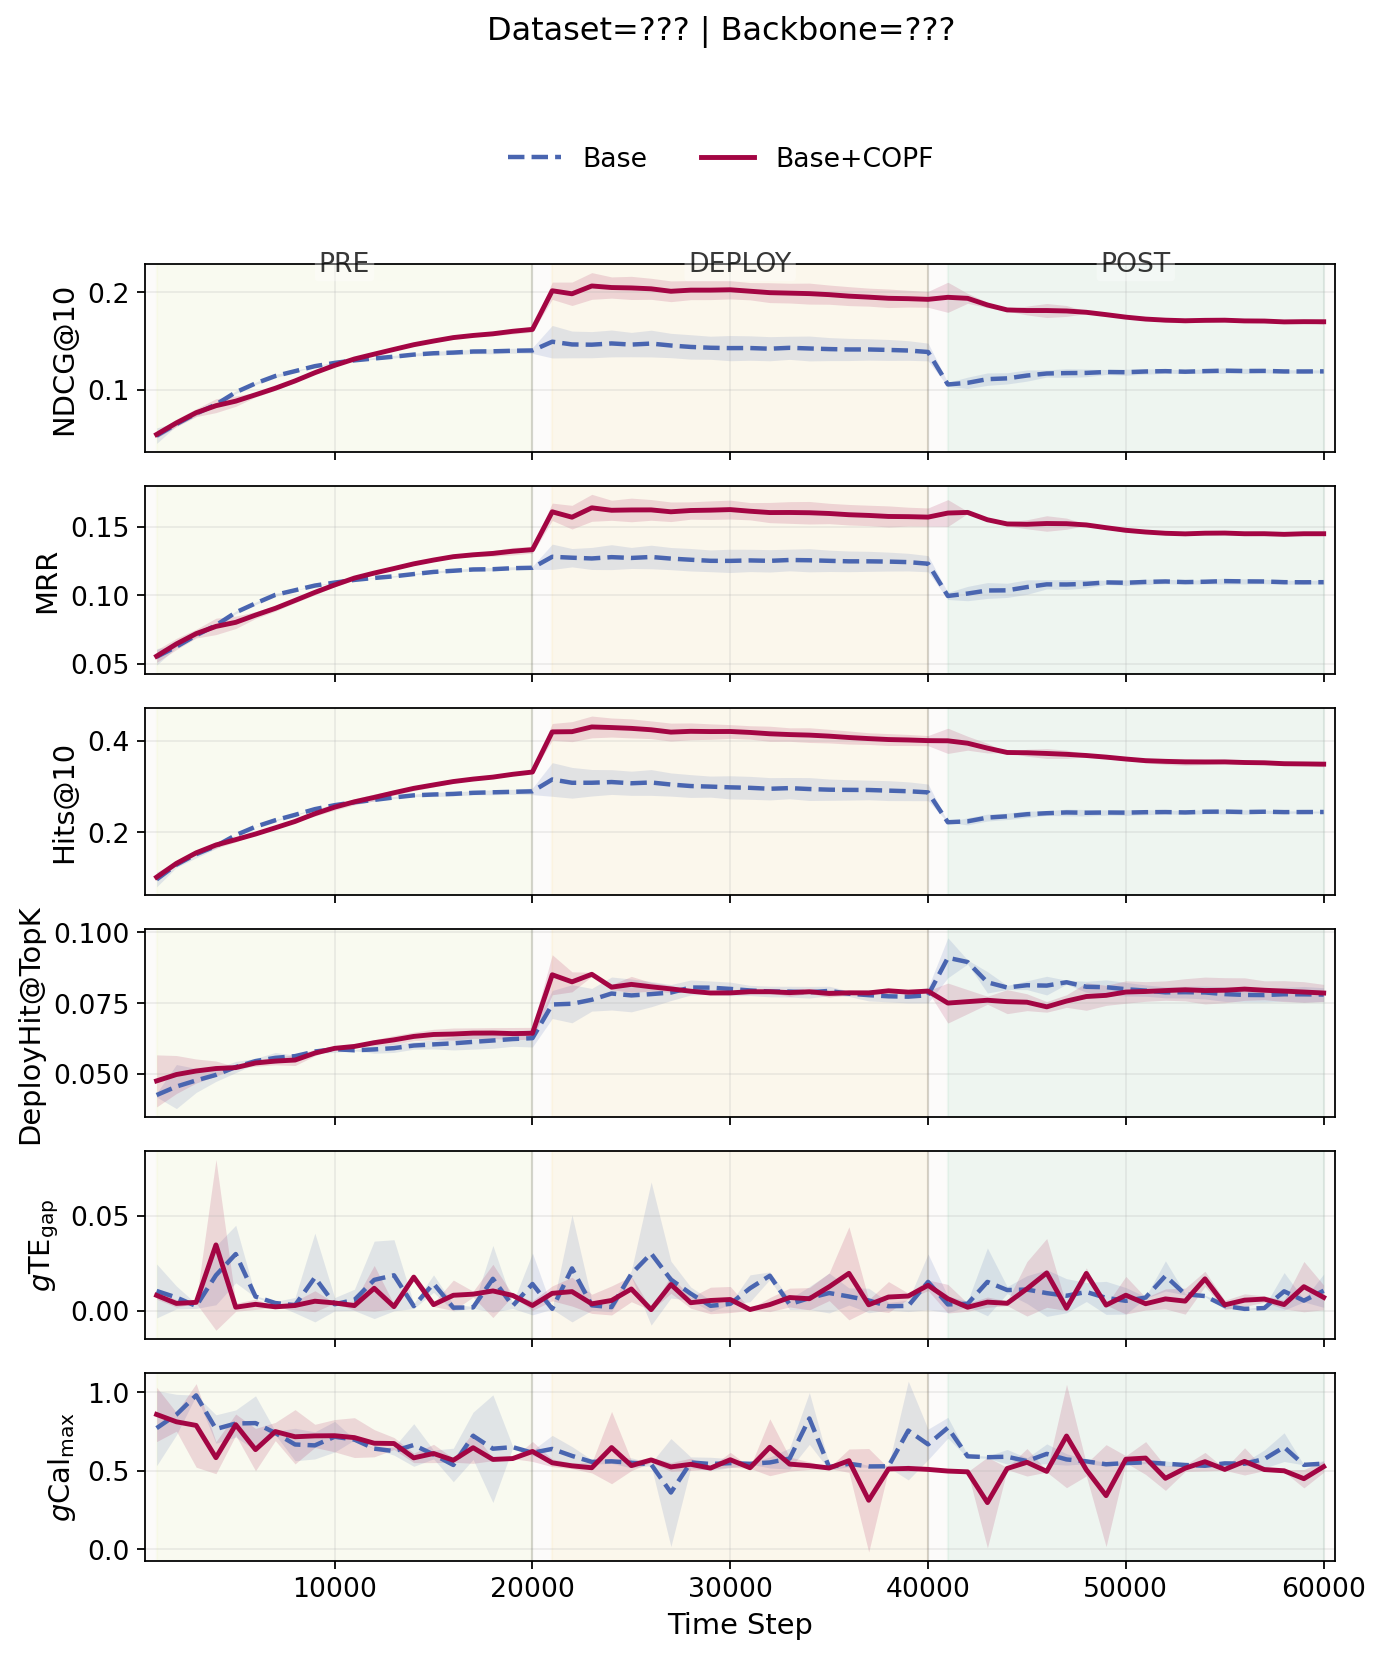

Saved: copf_timeseries_mean_std.pdf and copf_timeseries_mean_std.png


In [27]:
# ====== Plot (mean ± std with phase background) ======
fig, axes = plot_timeseries(
    base, copf,
    utility_metrics=UTILITY_METRICS,
    fairness_metrics=FAIRNESS_METRICS,
    title=TITLE,
    smooth_window=SMOOTH_WINDOW,
    show_seed_lines=SHOW_SEED_LINES,
    show_std_shade=SHOW_STD_SHADE,
    out_pdf=OUT_FIG_PDF,
    out_png=OUT_FIG_PNG,
)
plt.show()
print("Saved:", OUT_FIG_PDF, "and", OUT_FIG_PNG)


In [10]:
# ====== Phase summary table (for paper) ======
metrics_all = UTILITY_METRICS + FAIRNESS_METRICS
higher_is_better = {m: True for m in UTILITY_METRICS}
higher_is_better.update({m: False for m in FAIRNESS_METRICS})

base_sum = phase_summary_table(base, metrics_all, higher_is_better)
copf_sum = phase_summary_table(copf, metrics_all, higher_is_better)

def pretty(df_sum, name):
    cols = ["phase"] + metrics_all
    out = df_sum[cols].copy()
    out = out.rename(columns={m: _label(m) for m in metrics_all})
    print(f"\n== {name} ==")
    display(out)

pretty(base_sum, "Base")
pretty(copf_sum, "Base+COPF")


KeyError: "Columns not found: 'gTE_gap', 'gCal_max'"

In [ ]:
import os, re
from io import StringIO
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Optional: docx parsing fallback
try:
    from docx import Document
    DOCX_OK = True
except Exception:
    DOCX_OK = False

def _normalize_cols(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = [c.strip() for c in df.columns]
    # standardize some common variants
    rename = {
        "ndcg": "ndcg@10",
        "ndcg10": "ndcg@10",
        "hits10": "hits@10",
        "hit@10": "hits@10",
        "deploy_hit": "deploy_hit@topk",
        "deploy_hit@k": "deploy_hit@topk",
        "gte_gap": "gTE_gap",
        "gcal_max": "gCal_max",
        "phase ": "phase",
        "step ": "step",
    }
    df = df.rename(columns={k:v for k,v in rename.items() if k in df.columns})
    # force basic cols
    if "phase" in df.columns:
        df["phase"] = df["phase"].astype(str).str.strip().str.lower()
    if "step" in df.columns:
        df["step"] = pd.to_numeric(df["step"], errors="coerce")
    return df

def _infer_seed_col(df: pd.DataFrame, candidates=SEED_COL_CANDIDATES) -> str:
    for c in candidates:
        if c in df.columns:
            return c
    return ""  # none

def _ensure_seed_col(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    seed_col = _infer_seed_col(df)
    if not seed_col:
        df["seed"] = 0
    else:
        df = df.rename(columns={seed_col: "seed"})
    df["seed"] = pd.to_numeric(df["seed"], errors="coerce").fillna(0).astype(int)
    return df

def load_csv(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    df = _normalize_cols(df)
    df = _ensure_seed_col(df)
    return df

def load_docx_as_df(path: str) -> pd.DataFrame:
    if not DOCX_OK:
        raise RuntimeError("python-docx is not installed in your env, cannot load .docx.")
    doc = Document(path)
    text = "\n".join(p.text for p in doc.paragraphs)
    lines = [ln.strip() for ln in text.splitlines()]

    # Extract every CSV chunk starting with 'step,phase,'
    chunks = []
    i = 0
    while i < len(lines):
        ln = lines[i]
        if ln.lower().startswith("step,phase,"):
            header = ln
            data = [header]
            i += 1
            while i < len(lines) and re.match(r"^\d+", lines[i] or ""):
                data.append(lines[i])
                i += 1
            chunks.append("\n".join(data))
        else:
            i += 1

    dfs = []
    for idx, chunk in enumerate(chunks):
        dfi = pd.read_csv(StringIO(chunk))
        dfi = _normalize_cols(dfi)
        # try to infer seed/round from surrounding text is hard; fallback:
        # if docx contains multiple rounds, it's often stored as separate chunks in order.
        dfi["seed"] = idx
        dfs.append(dfi)

    df = pd.concat(dfs, ignore_index=True)
    return df

def load_any(path: str) -> pd.DataFrame:
    ext = os.path.splitext(path)[1].lower()
    if ext == ".csv":
        return load_csv(path)
    if ext == ".docx":
        return load_docx_as_df(path)
    raise ValueError(f"Unsupported file type: {ext}")

def get_phase_boundaries(df: pd.DataFrame):
    """Return (deploy_start_step, post_start_step)."""
    df1 = df.sort_values("step").dropna(subset=["step"])
    deploy_steps = df1.loc[df1["phase"] == "deploy", "step"]
    post_steps   = df1.loc[df1["phase"] == "post", "step"]
    deploy_start = float(deploy_steps.min()) if len(deploy_steps) else None
    post_start   = float(post_steps.min()) if len(post_steps) else None
    return deploy_start, post_start

def aggregate_steps(df: pd.DataFrame, metric: str):
    """Aggregate metric over seeds per step: returns columns [step, mean, std]."""
    d = df.dropna(subset=["step"]).copy()
    if metric not in d.columns:
        raise KeyError(f"Metric '{metric}' not found. Available columns: {list(d.columns)}")
    d[metric] = pd.to_numeric(d[metric], errors="coerce")
    # If duplicates exist for (seed, step), average them first.
    d = d.groupby(["seed", "step"], as_index=False)[metric].mean()
    stats = d.groupby("step")[metric].agg(["mean", "std"]).reset_index()
    return stats

def smooth_series(x: pd.Series, window: int):
    if window is None or window <= 1:
        return x
    return x.rolling(window, min_periods=1, center=True).mean()

def plot_timeseries(base: pd.DataFrame, copf: pd.DataFrame,
                    utility_metrics, fairness_metrics,
                    title="", smooth_window=1,
                    show_seed_lines=True, show_std_shade=True,
                    out_fig=None):
    metrics = list(utility_metrics) + list(fairness_metrics)
    # create rows = len(metrics), 1 column (cleaner than grids)
    n = len(metrics)
    fig, axes = plt.subplots(n, 1, figsize=(8.2, 1.75*n), sharex=True, constrained_layout=True)
    if n == 1:
        axes = [axes]

    # phase boundaries from merged df
    merged = pd.concat([base, copf], ignore_index=True)
    d0, d1 = get_phase_boundaries(merged)

    for ax, metric in zip(axes, metrics):
        # mean ± std
        b = aggregate_steps(base, metric)
        c = aggregate_steps(copf, metric)

        b_mean = smooth_series(b["mean"], smooth_window)
        c_mean = smooth_series(c["mean"], smooth_window)

        ax.plot(b["step"], b_mean, label="Base")
        ax.plot(c["step"], c_mean, label="Base+COPF")

        if show_std_shade:
            if not np.all(np.isnan(b["std"])) and b["std"].notna().any():
                ax.fill_between(b["step"], b_mean - b["std"].fillna(0), b_mean + b["std"].fillna(0), alpha=0.15)
            if not np.all(np.isnan(c["std"])) and c["std"].notna().any():
                ax.fill_between(c["step"], c_mean - c["std"].fillna(0), c_mean + c["std"].fillna(0), alpha=0.15)

        # optional per-seed lines (thin)
        if show_seed_lines and base["seed"].nunique() > 1:
            for s, ds in base.groupby("seed"):
                if metric not in ds.columns: 
                    continue
                ds = ds.sort_values("step")
                ax.plot(ds["step"], smooth_series(pd.to_numeric(ds[metric], errors='coerce'), smooth_window),
                        linewidth=0.6, alpha=0.12)
        if show_seed_lines and copf["seed"].nunique() > 1:
            for s, ds in copf.groupby("seed"):
                if metric not in ds.columns: 
                    continue
                ds = ds.sort_values("step")
                ax.plot(ds["step"], smooth_series(pd.to_numeric(ds[metric], errors='coerce'), smooth_window),
                        linewidth=0.6, alpha=0.12)

        # phase markers
        if d0 is not None:
            ax.axvline(d0, linestyle="--", linewidth=1.0, alpha=0.7)
        if d1 is not None:
            ax.axvline(d1, linestyle="--", linewidth=1.0, alpha=0.7)

        ax.set_ylabel(metric)
        ax.grid(True, alpha=0.25)

    axes[0].set_title(title)
    axes[-1].set_xlabel("Time step")

    # single legend
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles[:2], labels[:2], loc="upper right", frameon=False)

    if out_fig:
        fig.savefig(out_fig, bbox_inches="tight")
        print(f"Saved: {out_fig}")
    return fig, axes

def phase_summary_table(df: pd.DataFrame, metrics, higher_is_better):
    """Return phase summary: mean±std over seeds, and worst-case within phase (over steps and seeds)."""
    d = df.copy()
    d = d.dropna(subset=["step"])
    d["phase"] = d["phase"].astype(str).str.lower()
    # per seed per phase mean
    per_seed = d.groupby(["seed","phase"], as_index=False)[metrics].mean()

    rows = []
    for phase in ["pre","deploy","post"]:
        ps = per_seed[per_seed["phase"] == phase]
        if ps.empty:
            continue

        # worst-case: computed on raw (step-level) values aggregated over all seeds
        raw_phase = d[d["phase"] == phase]

        row = {"phase": phase}
        for m in metrics:
            mu = ps[m].mean()
            sd = ps[m].std(ddof=1) if ps[m].nunique() > 1 else 0.0

            if higher_is_better.get(m, True):
                worst = raw_phase[m].min()
            else:
                worst = raw_phase[m].max()
            row[m] = f"{mu:.4f}±{sd:.4f} ({worst:.4f})"
        rows.append(row)

    return pd.DataFrame(rows).set_index("phase")



In [ ]:
# ====== Load data ======
base = load_any(BASE_PATH)
copf = load_any(COPF_PATH)

# Keep only rows with known phases
base = base[base["phase"].isin(["pre","deploy","post"])].copy()
copf = copf[copf["phase"].isin(["pre","deploy","post"])].copy()

print("Base shape:", base.shape, "| seeds:", base["seed"].nunique())
print("COPF shape:", copf.shape, "| seeds:", copf["seed"].nunique())
print("Columns:", list(base.columns))


In [ ]:
# ====== Plot time-series ======
fig, axes = plot_timeseries(
    base, copf,
    utility_metrics=UTILITY_METRICS,
    fairness_metrics=FAIRNESS_METRICS,
    title=TITLE,
    smooth_window=SMOOTH_WINDOW,
    show_seed_lines=SHOW_SEED_LINES,
    show_std_shade=SHOW_STD_SHADE,
    out_fig=OUT_FIG,
)
plt.show()


In [ ]:
# ====== Phase summary (for paper tables) ======
utility_higher = {m: True for m in UTILITY_METRICS}
fairness_higher = {m: False for m in FAIRNESS_METRICS}  # lower is better
hib = {**utility_higher, **fairness_higher}

print("== Base phase summary ==")
display(phase_summary_table(base, UTILITY_METRICS + FAIRNESS_METRICS, higher_is_better=hib))

print("\n== COPF phase summary ==")
display(phase_summary_table(copf, UTILITY_METRICS + FAIRNESS_METRICS, higher_is_better=hib))


## Optional: a more “paper-style” trade-off plot

This compresses each phase into a point:
- x-axis = utility (e.g. NDCG@10) higher is better
- y-axis = fairness (e.g. gTE_gap) lower is better

Then it draws an arrow from Base → Base+COPF for each phase.


In [ ]:
def phase_point(df: pd.DataFrame, metric_x: str, metric_y: str):
    # per seed per phase mean, then average across seeds
    d = df.copy()
    d[metric_x] = pd.to_numeric(d[metric_x], errors='coerce')
    d[metric_y] = pd.to_numeric(d[metric_y], errors='coerce')
    per_seed = d.groupby(['seed','phase'], as_index=False)[[metric_x, metric_y]].mean()
    pts = per_seed.groupby('phase')[[metric_x, metric_y]].agg(['mean','std'])
    return pts

def plot_tradeoff(base, copf, metric_x="ndcg@10", metric_y="gTE_gap", title="Trade-off"):
    b = phase_point(base, metric_x, metric_y)
    c = phase_point(copf, metric_x, metric_y)

    phases = ["pre","deploy","post"]
    fig, ax = plt.subplots(figsize=(6.5, 4.5), constrained_layout=True)
    for ph in phases:
        if ph not in b.index or ph not in c.index:
            continue
        bx, by = b.loc[ph, (metric_x,'mean')], b.loc[ph, (metric_y,'mean')]
        cx, cy = c.loc[ph, (metric_x,'mean')], c.loc[ph, (metric_y,'mean')]

        ax.scatter([bx], [by], marker="o")
        ax.scatter([cx], [cy], marker="^")
        ax.annotate(ph.upper(), (bx, by), textcoords="offset points", xytext=(5,5), fontsize=9)

        ax.annotate("", xy=(cx, cy), xytext=(bx, by),
                    arrowprops=dict(arrowstyle="->", linewidth=1.2, alpha=0.8))

    ax.set_xlabel(metric_x + " (higher better)")
    ax.set_ylabel(metric_y + " (lower better)")
    ax.set_title(title)
    ax.grid(True, alpha=0.25)
    return fig, ax

fig, ax = plot_tradeoff(base, copf, metric_x="ndcg@10", metric_y="gTE_gap",
                        title=f"{TITLE} | Trade-off")
plt.show()
